In [1]:
import pandas as pd

# Cleaning

In [3]:
q_path = "/Users/elmiraonagh/Desktop/Research/ICSE2026_specification/ICSE26_specification/data/questionnair.csv"
df = pd.read_csv(q_path)
mode_list = df['Q1'].dropna().mode()[0]
df['Q1'] = df['Q1'].apply(lambda x: mode_list if pd.isna(x) else x)
df['Q1'] = df['Q1'].apply(lambda x: mode_list if x == "others" else x)
mode_list = df['Q2'].dropna().mode()[0]
df['Q2'] = df['Q2'].apply(lambda x: mode_list if pd.isna(x) else x)
mode_list = df['Q3'].dropna().mode()[0]
df['Q3'] = df['Q3'].apply(lambda x: mode_list if pd.isna(x) else x)
mode_list = df['Q5'].dropna().mode()[0]
df['Q5'] = df['Q5'].apply(lambda x: mode_list if pd.isna(x) else x)
df


,Q1,Q2,Q3,Q4,Q5,anon_id
0,4,CS,2.0,"[3, 4]",1.0,S0041
1,4,CE,4.0,"[2, 3, 4, 5]",1.0,S0066
2,4,SE,2.0,"[3, 4]",1.0,S0057
3,4,SE,3.0,"[2, 4]",1.0,NaN
4,4,CE,4.0,"[2, 3]",1.0,S0008
...,...,...,...,...,...,...
67,4,CS,4.0,"[1, 2, 3, 4]",4.0,S0037
68,4,CS,5.0,"[1, 2, 3, 4, 5]",4.0,S0038
69,5,CS,4.0,"[1, 2, 3, 5]",3.0,S0049
70,5,CS,4.0,"[1, 3, 4]",5.0,S0053


In [4]:
import ast
import pandas as pd

def safe_eval(x):
    if pd.isna(x):
        return None  # or [] depending on your preference
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return None  # fallback for bad strings

df["Q4"] = df["Q4"].apply(safe_eval)

In [5]:
from collections import Counter

all_values = df['Q4'].dropna().explode()
most_common = [x for x, _ in Counter(all_values).most_common(3)]  # top 3

In [6]:
def fill_q4(x):
    if x is None:
        return most_common
    if isinstance(x, float) and pd.isna(x):
        return most_common
    if isinstance(x, list) and len(x) == 0:
        return most_common
    return x

df['Q4'] = df['Q4'].apply(fill_q4)

In [7]:
counts = df["Q1"].value_counts()
percent = df["Q1"].value_counts(normalize=True) * 100

result = pd.DataFrame({
    "count": counts,
    "percent": percent.round(2)
})

print("Year in schol")
result
### year in the school

Year in schol


,count,percent
Q1,,
4,54,75.00
5,12,16.67
3,6,8.33


In [8]:
df["Q2"].value_counts()
#### major

Q2
SE        34
CE        20
CS        17
others     1
Name: count, dtype: int64

In [9]:
# Q3. To what extent do you use Large Language Models (LLMs) for coding? (e.g., ChatGPT, Copilot).
# 1 Never
# 2 Rarely (a few times per semester)
# 3 Sometimes (monthly)
# 4 Often (weekly)
# 5 Very often (daily or almost daily)

df["Q3"].value_counts()

Q3
4.0    31
3.0    23
2.0    10
5.0     7
1.0     1
Name: count, dtype: int64

In [10]:
# Q5. To What extent are you confident in your python skill?
#  Not confident at all
#  Slightly confident
#  Moderately confident
#  Very confident
#  Extremely confident

df["Q5"].value_counts()


Q5
3.0    32
2.0    19
4.0    12
1.0     6
5.0     3
Name: count, dtype: int64

# Year

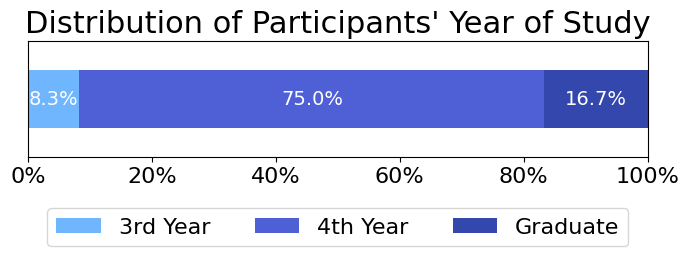

In [66]:
import pandas as pd
import matplotlib.pyplot as plt

# Map numeric to year labels
year_labels = {'3': "3rd Year", '4': "4th Year", '5': "Graduate"}
q1_labeled = df['Q1'].astype(str)  # ensure keys match strings in year_labels

# Compute percentages
q1_percent = q1_labeled.value_counts(normalize=True).sort_index() * 100

# Convert to single-row DataFrame for stacking
q1_df = pd.DataFrame([q1_percent])

# Plot stacked horizontal bar
colors = ["#6fb6ff", "#4f5fd5", "#3347ac"]  # optional colors
ax = q1_df.plot(
    kind='barh',
    stacked=True,
    figsize=(8, 2),
    color=colors,
    legend=False  # disable automatic legend
)

ax.set_title("Distribution of Participants' Year of Study", fontsize=22,)
ax.set_xlabel("")
ax.set_yticks([])  # remove y-axis entirely
ax.set_ylabel("")  # ensure no label
ax.set_xlim(0, 100)

# Set x-axis ticks as percents
ax.set_xticks(range(0, 101, 20))
ax.set_xticklabels([f"{x}%" for x in range(0, 101, 20)])

# Add % labels inside each segment
for i, val in enumerate(q1_percent):
    if val > 5:
        ax.text(
            q1_percent[:i].sum() + val/2, 0, f"{val:.1f}%", 
            ha='center', va='center', color='white', fontsize=14
        )

# Custom legend labels
custom_labels = [year_labels[k] for k in q1_percent.keys()]

# Put legend under the plot with proper margin
ax.legend(
    handles=ax.patches[:len(custom_labels)],  # pick only one patch per segment
    labels=custom_labels,
    title="",
    bbox_to_anchor=(0.5, -0.35),  # adjust up/down as needed
    loc="upper center",
    ncol=len(custom_labels), 
    fontsize=16
)

# Adjust bottom margin to avoid overlap
plt.subplots_adjust(bottom=0.3)
plt.savefig("/Users/elmiraonagh/Desktop/Research/Specification_proj_w26/specification_repo/Specification-Completeness-and-Failure-Modes-in-LLM-Assisted-Development/img/demo_year.pdf", bbox_inches='tight', dpi=300)
plt.show()

# major

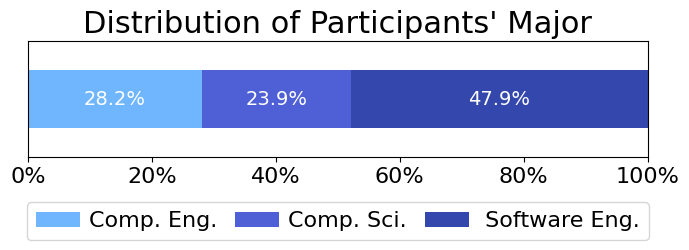

In [84]:
import pandas as pd
import matplotlib.pyplot as plt

# # Map numeric to year labels
# year_labels = {'CE': "Computer Eng.", 'CS': "Computer Science", 'SE': "Software Eng.", "others": "Others"}
# q1_labeled = df['Q2'].astype(str)  # ensure keys match strings in year_labels

# Short labels (already compact)
year_labels = {
    'CE': "Comp. Eng.",
    'CS': "Comp. Sci.",
    'SE': " Software Eng."
}

# Filter out "others"
df_filtered = df[df['Q2'].isin(year_labels.keys())].copy()

q1_labeled = df_filtered['Q2'].astype(str)
# Compute percentages
q1_percent = q1_labeled.value_counts(normalize=True).sort_index() * 100

# Convert to single-row DataFrame for stacking
q1_df = pd.DataFrame([q1_percent])

# Plot stacked horizontal bar
colors = ["#6fb6ff", "#4f5fd5", "#3347ac", "#502977"]  # optional colors
ax = q1_df.plot(
    kind='barh',
    stacked=True,
    figsize=(8, 2),
    color=colors,
    legend=False  # disable automatic legend
)

ax.set_title("Distribution of Participants' Major", fontsize=22,)
ax.set_xlabel("")
ax.set_yticks([])  # remove y-axis entirely
ax.set_ylabel("")  # ensure no label
ax.set_xlim(0, 100)

# Set x-axis ticks as percents
ax.set_xticks(range(0, 101, 20))
ax.set_xticklabels([f"{x}%" for x in range(0, 101, 20)])

# Add % labels inside each segment
for i, val in enumerate(q1_percent):
    if val > 5:
        ax.text(
            q1_percent[:i].sum() + val/2, 0, f"{val:.1f}%", 
            ha='center', va='center', color='white', fontsize=14
        )

# Custom legend labels
custom_labels = [year_labels[k] for k in q1_percent.keys()]

# Put legend under the plot with proper margin
# ax.legend(
#     handles=ax.patches[:len(custom_labels)],  # pick only one patch per segment
#     labels=custom_labels,
#     title="",
#     bbox_to_anchor=(0.5, -0.35),  # adjust up/down as needed
#     loc="upper center",
#     ncol=len(custom_labels), 
#     fontsize=16
# )
ax.legend(
    handles=ax.patches[:len(custom_labels)],
    labels=custom_labels,
    title="",
    bbox_to_anchor=(0.5, -0.35),
    loc="upper center",
    ncol=len(custom_labels),

    fontsize=16,
    columnspacing=0.8,   # ⬅️ reduces space between legend columns
    handletextpad=0.4,   # ⬅️ reduces space between marker and text
    borderaxespad=0.2,   # ⬅️ reduces outer padding
    labelspacing=0.3     # ⬅️ vertical spacing (less relevant here but helpful)
)
# Adjust bottom margin to avoid overlap
plt.subplots_adjust(bottom=0.3)
plt.savefig("/Users/elmiraonagh/Desktop/Research/Specification_proj_w26/specification_repo/Specification-Completeness-and-Failure-Modes-in-LLM-Assisted-Development/img/demo_major.pdf", bbox_inches='tight', dpi=300)
plt.show()

# LLM usage

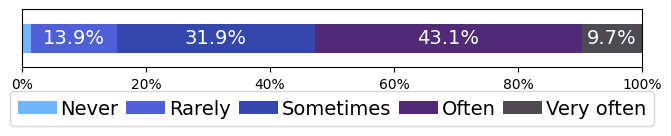

In [18]:
# Q3. To what extent do you use Large Language Models (LLMs) for coding? (e.g., ChatGPT, Copilot).
# 1 Never
# 2 Rarely (a few times per semester)
# 3 Sometimes (monthly)
# 4 Often (weekly)
# 5 Very often (daily or almost daily)

import pandas as pd
import matplotlib.pyplot as plt

# Map numeric to year labels
year_labels = {'1.0': "Never", '2.0': "Rarely", '3.0': "Sometimes", "4.0": "Often", "5.0": "Very often"}
q1_labeled = df['Q3'].astype(str)  # ensure keys match strings in year_labels

# Compute percentages
q1_percent = q1_labeled.value_counts(normalize=True).sort_index() * 100

# Convert to single-row DataFrame for stacking
q1_df = pd.DataFrame([q1_percent])

# Plot stacked horizontal bar
colors = ["#6fb6ff", "#4f5fd5", "#3347ac", "#502977", "#4D4B50"]  # optional colors
ax = q1_df.plot(
    kind='barh',
    stacked=True,
    figsize=(8, 1),
    color=colors,
    legend=False  # disable automatic legend
)

# ax.set_title("Particiapant Self-reported LLM Usage", fontsize=22,)
ax.set_xlabel("")
ax.set_yticks([])  # remove y-axis entirely
ax.set_ylabel("")  # ensure no label
ax.set_xlim(0, 100)

# Set x-axis ticks as percents
ax.set_xticks(range(0, 101, 20))
ax.set_xticklabels([f"{x}%" for x in range(0, 101, 20)])

# Add % labels inside each segment
for i, val in enumerate(q1_percent):
    if val > 5:
        ax.text(
            q1_percent[:i].sum() + val/2, 0, f"{val:.1f}%", 
            ha='center', va='center', color='white', fontsize=14
        )

# Custom legend labels
custom_labels = [year_labels[k] for k in q1_percent.keys()]

# Put legend under the plot with proper margin
ax.legend(
    handles=ax.patches[:len(custom_labels)],
    labels=custom_labels,
    title="",
    bbox_to_anchor=(0.5, -0.35),
    loc="upper center",
    ncol=len(custom_labels),

    fontsize=14,
    columnspacing=0.4,   # ⬅️ reduces space between legend columns
    handletextpad=0.2,   # ⬅️ reduces space between marker and text
    borderaxespad=0.2,   # ⬅️ reduces outer padding
    labelspacing=0.1     # ⬅️ vertical spacing (less relevant here but helpful)
)

# Adjust bottom margin to avoid overlap
plt.subplots_adjust(bottom=0.3)
plt.savefig("/Users/elmiraonagh/Desktop/Research/ICSE2026_specification/ICSE26_specification/img/demo_llm_use.pdf", bbox_inches='tight', dpi=300)
plt.show()

# python skill

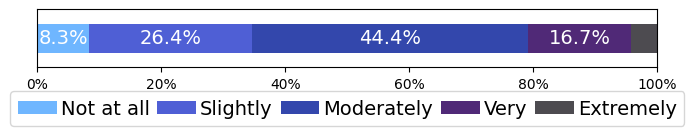

In [17]:
# Q5. To What extent are you confident in your python skill?
#  Not confident at all
#  Slightly confident
#  Moderately confident
#  Very confident
#  Extremely confident

import pandas as pd
import matplotlib.pyplot as plt

# Map numeric to year labels
year_labels = {'1.0': "Not at all", '2.0': "Slightly", '3.0': 
               "Moderately", "4.0": "Very", "5.0": "Extremely"}
q1_labeled = df['Q5'].astype(str)  # ensure keys match strings in year_labels

# Compute percentages
q1_percent = q1_labeled.value_counts(normalize=True).sort_index() * 100

# Convert to single-row DataFrame for stacking
q1_df = pd.DataFrame([q1_percent])

# Plot stacked horizontal bar
colors = ["#6fb6ff", "#4f5fd5", "#3347ac", "#502977", "#4D4B50"]  # optional colors
ax = q1_df.plot(
    kind='barh',
    stacked=True,
    figsize=(8, 1),
    color=colors,
    legend=False  # disable automatic legend
)

# ax.set_title("Particiapant Self-reported Python Familiarity", fontsize = 21)
ax.set_xlabel("")
ax.set_yticks([])  # remove y-axis entirely
ax.set_ylabel("")  # ensure no label
ax.set_xlim(0, 100)

# Set x-axis ticks as percents
ax.set_xticks(range(0, 101, 20))
ax.set_xticklabels([f"{x}%" for x in range(0, 101, 20)])

# Add % labels inside each segment
for i, val in enumerate(q1_percent):
    if val > 5:
        ax.text(
            q1_percent[:i].sum() + val/2, 0, f"{val:.1f}%", 
            ha='center', va='center', color='white', fontsize=14
        )

# Custom legend labels
custom_labels = [year_labels[k] for k in q1_percent.keys()]

# Put legend under the plot with proper margin
# ax.legend(
#     handles=ax.patches[:len(custom_labels)],  # pick only one patch per segment
#     labels=custom_labels,
#     title="",
#     bbox_to_anchor=(0.5, -0.35),  # adjust up/down as needed
#     loc="upper center",
#     ncol=len(custom_labels)
# )
# Put legend under the plot with proper margin
ax.legend(
    handles=ax.patches[:len(custom_labels)],
    labels=custom_labels,
    title="",
    bbox_to_anchor=(0.5, -0.35),
    loc="upper center",
    ncol=len(custom_labels),

    fontsize=14,
    columnspacing=0.4,   # ⬅️ reduces space between legend columns
    handletextpad=0.2,   # ⬅️ reduces space between marker and text
    borderaxespad=0.2,   # ⬅️ reduces outer padding
    labelspacing=0.1     # ⬅️ vertical spacing (less relevant here but helpful)
)
# Adjust bottom margin to avoid overlap
plt.subplots_adjust(bottom=0.3)
plt.savefig("/Users/elmiraonagh/Desktop/Research/ICSE2026_specification/ICSE26_specification/img/demo_python.pdf", bbox_inches='tight', dpi=300)
plt.show()


# LLM interactions

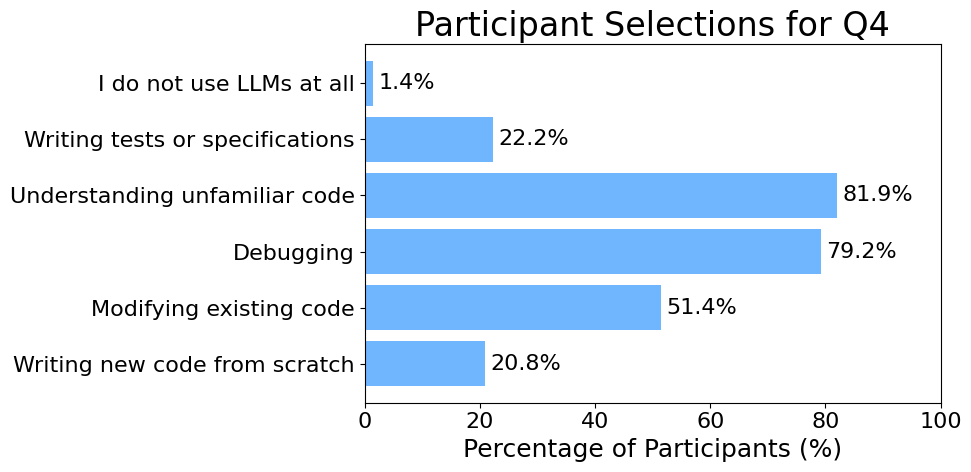

In [95]:
import pandas as pd
import matplotlib.pyplot as plt

# Flatten the lists into a long series
all_values = df["Q4"].dropna().explode()

# Count how many participants selected each category at least once
# For multi-select, we count unique occurrences per participant
selection_counts = all_values.value_counts().sort_index()

# Convert to percentage of participants
percentages = selection_counts / len(df) * 100

# Map numeric codes to category labels
category_labels = {
    1: "Writing new code from scratch",
    2: "Modifying existing code",
    3: "Debugging",
    4: "Understanding unfamiliar code",
    5: "Writing tests or specifications", 
    6: "I do not use LLMs at all"
}

# Prepare data for plotting
y_labels = [category_labels[k] for k in percentages.index]
x_values = percentages.values

# Plot horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(y_labels, x_values, color="#6fb6ff")

ax.set_xlabel("Percentage of Participants (%)")
ax.set_xlim(0, 100)
ax.set_title("Participant Selections for Q4")

# Add percentage labels at the end of each bar
for bar in bars:
    width = bar.get_width()
    ax.text(width + 1, bar.get_y() + bar.get_height()/2,
            f"{width:.1f}%", va='center')

plt.tight_layout()
plt.show()

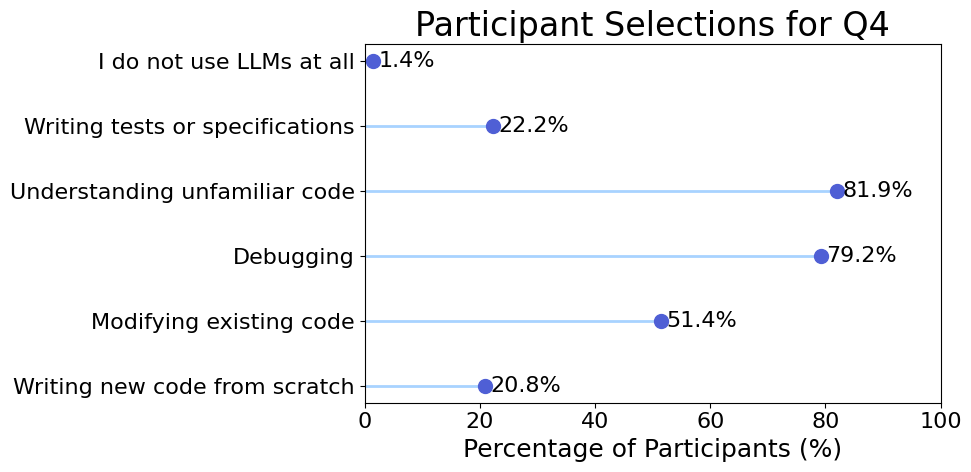

In [96]:
import pandas as pd
import matplotlib.pyplot as plt

# Flatten Q4 lists
all_values = df["Q4"].dropna().explode()

# Count how many participants selected each category at least once
selection_counts = all_values.value_counts().sort_index()

# Convert to percentage of participants
percentages = selection_counts / len(df) * 100

# Map numeric codes to category labels
category_labels = {
    1: "Writing new code from scratch",
    2: "Modifying existing code",
    3: "Debugging",
    4: "Understanding unfamiliar code",
    5: "Writing tests or specifications", 
    6: "I do not use LLMs at all"
}

# Prepare data
y_labels = [category_labels[k] for k in percentages.index]
x_values = percentages.values

# Plot lollipop chart
fig, ax = plt.subplots(figsize=(10, 5))

# Draw lines
ax.hlines(y=y_labels, xmin=0, xmax=x_values, color="#6fb6ff", alpha=0.6, linewidth=2)

# Draw dots
ax.plot(x_values, y_labels, "o", color="#4f5fd5", markersize=10)

# Labels and title
ax.set_xlabel("Percentage of Participants (%)")
ax.set_xlim(0, 100)
ax.set_title("Participant Selections for Q4")

# Add % labels at the end of lines
for i, value in enumerate(x_values):
    ax.text(value + 1, y_labels[i], f"{value:.1f}%", va='center')

plt.tight_layout()
plt.show()

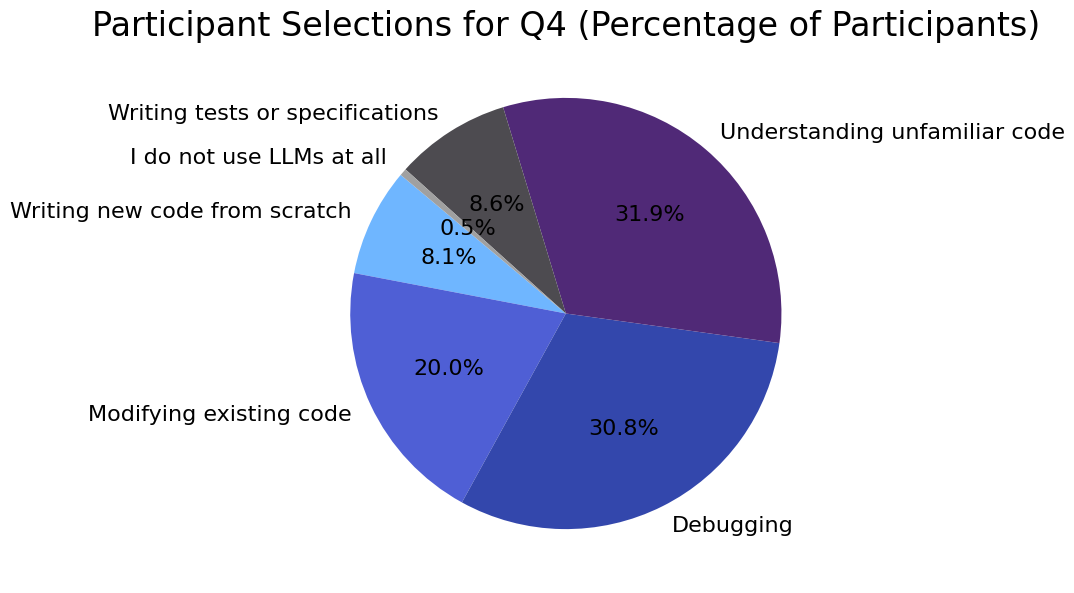

In [97]:
import pandas as pd
import matplotlib.pyplot as plt

# Flatten the lists into a long series
all_values = df["Q4"].dropna().explode()

# Count how many participants selected each category at least once
# For multi-select, each participant counts once per category
# Assuming df["Q4"] has one row per participant
selection_counts = {k: all_values[all_values == k].nunique() for k in all_values.unique()}

# Alternatively, since each row is one participant:
selection_counts = {}
for k in set(all_values):
    selection_counts[k] = df["Q4"].apply(lambda x: k in x if isinstance(x, list) else False).sum()

# Map numeric codes to category labels
category_labels = {
    1: "Writing new code from scratch",
    2: "Modifying existing code",
    3: "Debugging",
    4: "Understanding unfamiliar code",
    5: "Writing tests or specifications", 
    6: "I do not use LLMs at all"
}

# Prepare labels and values
labels = [category_labels[k] for k in sorted(selection_counts.keys())]
values = [selection_counts[k] for k in sorted(selection_counts.keys())]

# Compute percentages relative to total participants (72)
percentages = [v / 72 * 100 for v in values]

# Colors
colors = ["#6fb6ff", "#4f5fd5", "#3347ac", "#502977", "#4D4B50", "#a0a0a0"]

# Plot pie chart
plt.figure(figsize=(7,7))
plt.pie(percentages, labels=labels, autopct="%1.1f%%", startangle=140, colors=colors)
plt.title("Participant Selections for Q4 (Percentage of Participants)")
plt.show()

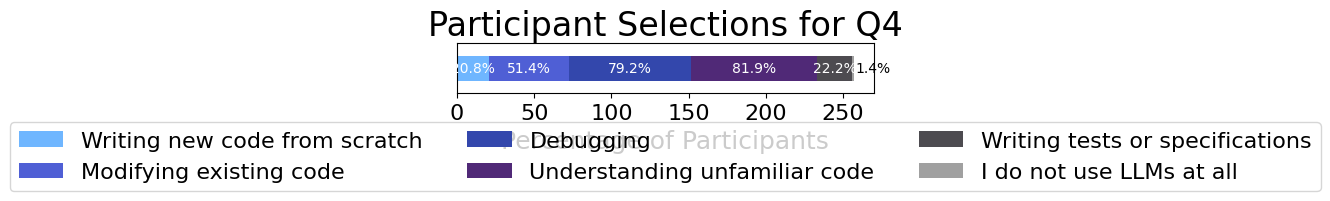

In [98]:
import pandas as pd
import matplotlib.pyplot as plt

# Total participants
total_participants = 72

# Count selections per category
selection_counts = {}
for k in range(1, 7):
    selection_counts[k] = df["Q4"].apply(lambda x: k in x if isinstance(x, list) else False).sum()

# Convert to percentages
percentages = [v / total_participants * 100 for v in selection_counts.values()]

# Map numeric codes to category labels
category_labels = {
    1: "Writing new code from scratch",
    2: "Modifying existing code",
    3: "Debugging",
    4: "Understanding unfamiliar code",
    5: "Writing tests or specifications", 
    6: "I do not use LLMs at all"
}

labels = [category_labels[k] for k in range(1, 7)]

# Convert to DataFrame
q4_df = pd.DataFrame([percentages], columns=labels)

# Colors
colors = ["#6fb6ff", "#4f5fd5", "#3347ac", "#502977", "#4D4B50", "#a0a0a0"]

# Plot
fig, ax = plt.subplots(figsize=(10, 2.5))  # wider figure
ax = q4_df.plot(
    kind='barh',
    stacked=True,
    color=colors,
    legend=False,
    ax=ax
)

ax.set_title("Participant Selections for Q4")
ax.set_xlabel("Percentage of Participants")
ax.set_ylabel("")
ax.set_yticks([])

# Dynamically set x-axis limit to sum + padding
ax.set_xlim(0, sum(percentages)*1.05)

# Add % labels inside or outside segments
for i, val in enumerate(percentages):
    xpos = sum(percentages[:i]) + val/2
    if val >= 5:
        ax.text(xpos, 0, f"{val:.1f}%", ha='center', va='center', color='white', fontsize=10)
    else:
        # small segments: label just outside
        ax.text(sum(percentages[:i]) + val + 1, 0, f"{val:.1f}%", ha='left', va='center', color='black', fontsize=10)

# Legend with 2 rows
ax.legend(
    handles=ax.patches[:len(labels)],
    labels=labels,
    bbox_to_anchor=(0.5, -0.35),
    loc="upper center",
    ncol=3
)

plt.subplots_adjust(bottom=0.45)  # extra bottom margin for 2-row legend
plt.tight_layout()
plt.show()

/var/folders/t8/pz3pwpn920vdzhd966m61fx80000gn/T/ipykernel_80725/378745133.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(y_labels, fontsize=18)


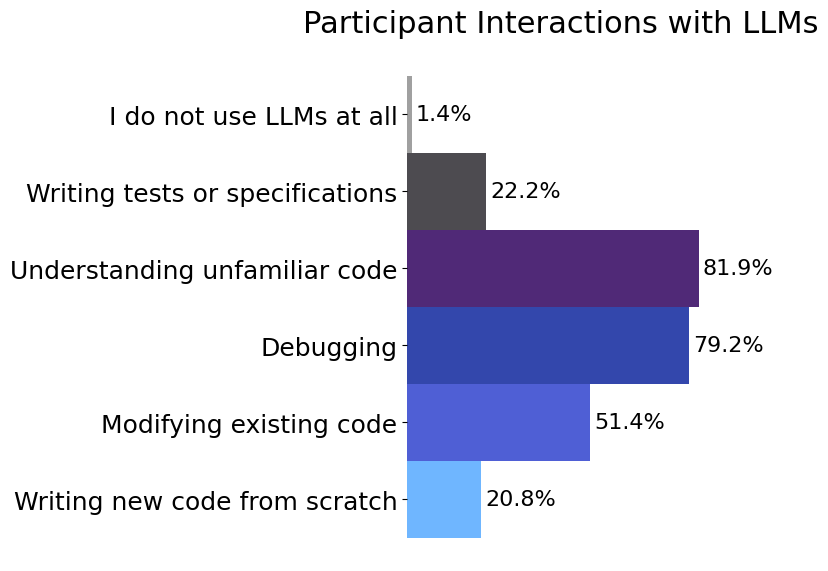

In [107]:
import pandas as pd
import matplotlib.pyplot as plt

# Flatten the lists into a long series
all_values = df["Q4"].dropna().explode()

# Count how many participants selected each category at least once
selection_counts = all_values.value_counts().sort_index()

# Convert to percentage of participants
percentages = selection_counts / len(df) * 100

# Map numeric codes to category labels
category_labels = {
    1: "Writing new code from scratch",
    2: "Modifying existing code",
    3: "Debugging",
    4: "Understanding unfamiliar code",
    5: "Writing tests or specifications", 
    6: "I do not use LLMs at all"
}

# Assign a color for each category
colors = ["#6fb6ff", "#4f5fd5", "#3347ac", "#502977", "#4D4B50", "#a0a0a0"]

# Prepare data for plotting
y_labels = [category_labels[k] for k in percentages.index]
x_values = percentages.values
bar_colors = [colors[k-1] for k in percentages.index]  # map each category to color

# Plot horizontal bar chart
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(y_labels, x_values, color=bar_colors, height=1.0)  # full height, no space

# Remove x-axis
ax.xaxis.set_visible(False)

# Remove all borders
for spine in ax.spines.values():
    spine.set_visible(False)

# Set larger title and y-axis labels
ax.set_title("Participant Interactions with LLMs", fontsize=22, pad=15)
ax.set_yticklabels(y_labels, fontsize=18)

# Add percentage labels at the end of each bar
for bar in bars:
    width = bar.get_width()
    ax.text(width + 1, bar.get_y() + bar.get_height()/2,
            f"{width:.1f}%", va='center', fontsize=16)

plt.tight_layout()
plt.savefig("/Users/elmiraonagh/Desktop/Research/Specification_proj_w26/specification_repo/Specification-Completeness-and-Failure-Modes-in-LLM-Assisted-Development/img/demo_llm_goal.pdf", bbox_inches='tight', dpi=300)
plt.show()

# overview

/var/folders/t8/pz3pwpn920vdzhd966m61fx80000gn/T/ipykernel_80725/1494035781.py:71: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(hspace=1.6)  # adjust vertical space between subplots
/var/folders/t8/pz3pwpn920vdzhd966m61fx80000gn/T/ipykernel_80725/1494035781.py:104: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(y_labels, fontsize=14)


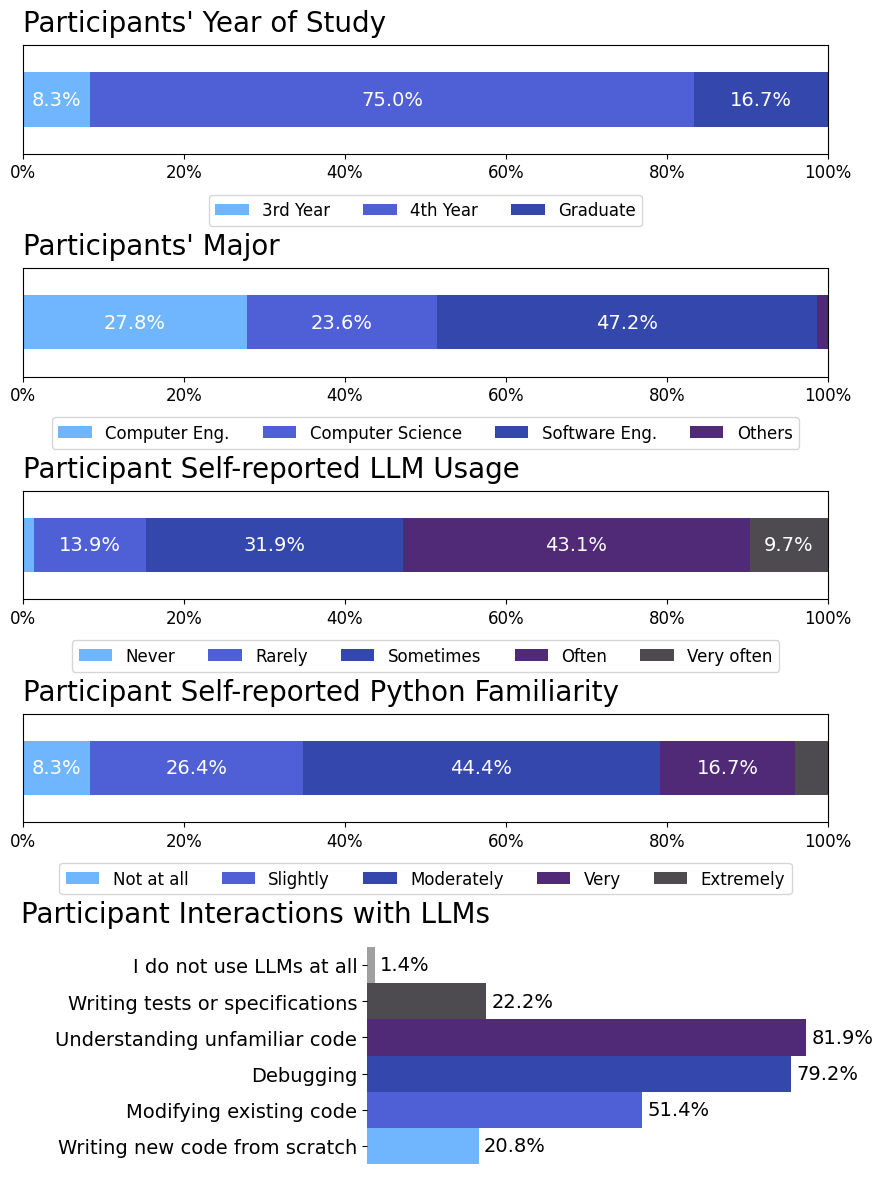

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# Define helper to plot stacked horizontal bars
# -------------------------
def plot_stacked_bar(ax, data_col, labels_map, colors, title):
    q_labeled = df[data_col].astype(str)
    q_percent = q_labeled.value_counts(normalize=True).sort_index() * 100
    q_df = pd.DataFrame([q_percent])

    q_df.plot(kind='barh', stacked=True, ax=ax, color=colors, legend=False)
    
    ax.set_title(title, fontsize=20, pad=10, loc='left')
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_yticks([])
    ax.set_xlim(0, 100)
    ax.set_xticks(range(0, 101, 20))
    ax.set_xticklabels([f"{x}%" for x in range(0, 101, 20)], fontsize=12)

    # Add percentage labels
    for i, val in enumerate(q_percent):
        if val > 5:
            ax.text(
                q_percent[:i].sum() + val/2, 0, f"{val:.1f}%",
                ha='center', va='center', color='white', fontsize=14
            )

    # Custom legend
    custom_labels = [labels_map[k] for k in q_percent.keys()]
    ax.legend(
        handles=ax.patches[:len(custom_labels)],
        labels=custom_labels,
        title="",
        bbox_to_anchor=(0.5, -0.3),
        loc="upper center",
        ncol=len(custom_labels),
        fontsize=12
    )

# -------------------------
# Define individual plots
# -------------------------
plots_info = [
    ("Q1", {'3': "3rd Year", '4': "4th Year", '5': "Graduate"}, ["#6fb6ff", "#4f5fd5", "#3347ac"], "Participants' Year of Study"),
    ("Q2", {'CE': "Computer Eng.", 'CS': "Computer Science", 'SE': "Software Eng.", "others": "Others"}, ["#6fb6ff", "#4f5fd5", "#3347ac", "#502977"], "Participants' Major"),
    ("Q3", {'1.0': "Never", '2.0': "Rarely", '3.0': "Sometimes", "4.0": "Often", "5.0": "Very often"}, ["#6fb6ff", "#4f5fd5", "#3347ac", "#502977", "#4D4B50"], "Participant Self-reported LLM Usage"),
    ("Q5", {'1.0': "Not at all", '2.0': "Slightly", '3.0': "Moderately", "4.0": "Very", "5.0": "Extremely"}, ["#6fb6ff", "#4f5fd5", "#3347ac", "#502977", "#4D4B50"], "Participant Self-reported Python Familiarity")
]

# -------------------------
# Create vertical figure
# -------------------------
fig, axes = plt.subplots(len(plots_info)+1, 1, figsize=(8.5, 10), constrained_layout=True)

for ax, (col, label_map, colors, title) in zip(axes[:-1], plots_info):
    ax_box = ax.get_position() 
    # ax.set_position([ax_box.x0, ax_box.y0, ax_box.width, ax_box.height])  # shrink height
    plot_stacked_bar(ax, col, label_map, colors, title)
    # Plot all except the last
# for ax, (col, label_map, colors, title) in zip(axes[:-1], plots_info):
#     plot_stacked_bar(ax, col, label_map, colors, title)

# Adjust the last subplot to be smaller vertically
last_ax = axes[-1]
last_box = last_ax.get_position()  # get current position
last_ax.set_position([last_box.x0+0.3, last_box.y0-0.28, last_box.width*0.7, last_box.height*1.8])  # shrink height

# Optional: tweak spacing so plots aren't overlapping
fig.subplots_adjust(hspace=1.6)  # adjust vertical space between subplots

# -------------------------
# Add the last Q4 horizontal bar chart (different style)
# -------------------------
# Flatten Q4 data
all_values = df["Q4"].dropna().explode()
selection_counts = all_values.value_counts().sort_index()
percentages = selection_counts / len(df) * 100
category_labels = {
    1: "Writing new code from scratch",
    2: "Modifying existing code",
    3: "Debugging",
    4: "Understanding unfamiliar code",
    5: "Writing tests or specifications", 
    6: "I do not use LLMs at all"
}
colors = ["#6fb6ff", "#4f5fd5", "#3347ac", "#502977", "#4D4B50", "#a0a0a0"]
y_labels = [category_labels[k] for k in percentages.index]
x_values = percentages.values
bar_colors = [colors[k-1] for k in percentages.index]

ax = axes[-1]
bars = ax.barh(y_labels, x_values, color=bar_colors, height=1)
# ax.set_title("Participant Interactions with LLMs", fontsize=20, pad=10, loc='left')
ax.set_title(
    "Participant Interactions with LLMs",
    fontsize=20,
    pad=10,
    loc='left',   # keeps left alignment
    x=-0.75    # shift further left; tweak as needed
)
ax.xaxis.set_visible(False)
ax.set_yticklabels(y_labels, fontsize=14)
for spine in ax.spines.values():
    spine.set_visible(False)
for bar in bars:
    width = bar.get_width()
    ax.text(width + 1, bar.get_y() + bar.get_height()/2, f"{width:.1f}%", va='center', fontsize=14)

# -------------------------
# Save the combined figure
# -------------------------
# plt.savefig("/Users/elmiraonagh/Desktop/Research/Specification_proj_w26/specification_repo/Specification-Completeness-and-Failure-Modes-in-LLM-Assisted-Development/img/demographic.pdf", bbox_inches='tight', dpi=300)
plt.show()

/var/folders/t8/pz3pwpn920vdzhd966m61fx80000gn/T/ipykernel_80725/826146580.py:94: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax5.set_yticklabels(y_labels, fontsize=14)


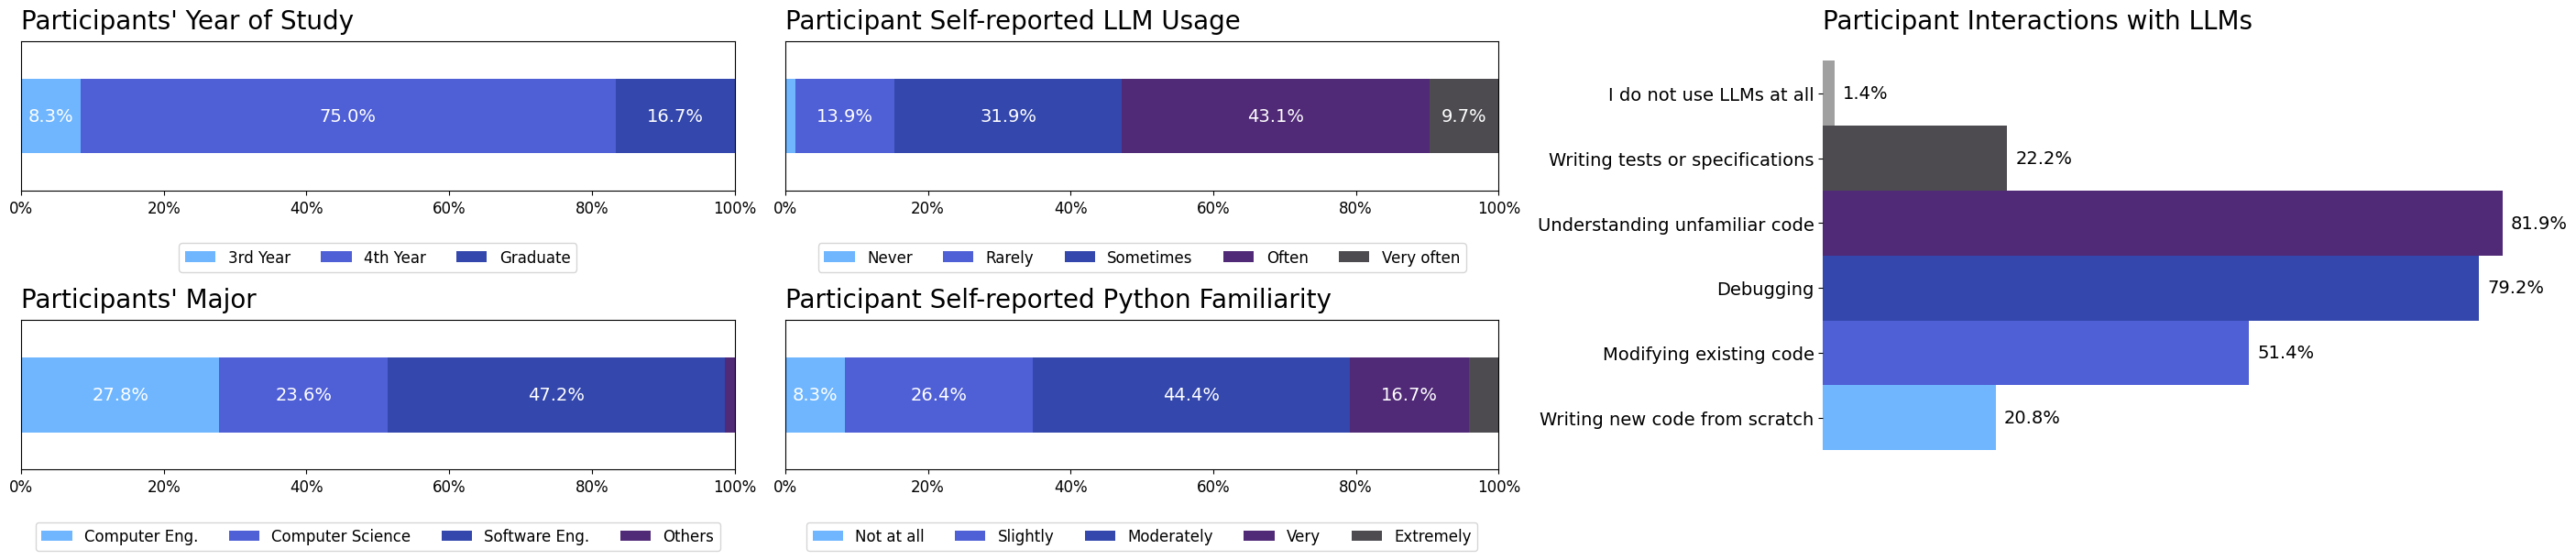

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# -------------------------
# Helper function (same as before)
# -------------------------
def plot_stacked_bar(ax, data_col, labels_map, colors, title):
    q_labeled = df[data_col].astype(str)
    q_percent = q_labeled.value_counts(normalize=True).sort_index() * 100
    q_df = pd.DataFrame([q_percent])

    q_df.plot(kind='barh', stacked=True, ax=ax, color=colors, legend=False)
    
    ax.set_title(title, fontsize=20, pad=10, loc='left')
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_yticks([])
    ax.set_xlim(0, 100)
    ax.set_xticks(range(0, 101, 20))
    ax.set_xticklabels([f"{x}%" for x in range(0, 101, 20)], fontsize=12)

    # Add percentage labels
    for i, val in enumerate(q_percent):
        if val > 5:
            ax.text(
                q_percent[:i].sum() + val/2, 0, f"{val:.1f}%",
                ha='center', va='center', color='white', fontsize=14
            )

    # Custom legend
    custom_labels = [labels_map[k] for k in q_percent.keys()]
    ax.legend(
        handles=ax.patches[:len(custom_labels)],
        labels=custom_labels,
        title="",
        bbox_to_anchor=(0.5, -0.3),
        loc="upper center",
        ncol=len(custom_labels),
        fontsize=12
    )

# -------------------------
# Plots info
# -------------------------
plots_info = [
    ("Q1", {'3': "3rd Year", '4': "4th Year", '5': "Graduate"}, ["#6fb6ff", "#4f5fd5", "#3347ac"], "Participants' Year of Study"),
    ("Q2", {'CE': "Computer Eng.", 'CS': "Computer Science", 'SE': "Software Eng.", "others": "Others"}, ["#6fb6ff", "#4f5fd5", "#3347ac", "#502977"], "Participants' Major"),
    ("Q3", {'1.0': "Never", '2.0': "Rarely", '3.0': "Sometimes", "4.0": "Often", "5.0": "Very often"}, ["#6fb6ff", "#4f5fd5", "#3347ac", "#502977", "#4D4B50"], "Participant Self-reported LLM Usage"),
    ("Q5", {'1.0': "Not at all", '2.0': "Slightly", '3.0': "Moderately", "4.0": "Very", "5.0": "Extremely"}, ["#6fb6ff", "#4f5fd5", "#3347ac", "#502977", "#4D4B50"], "Participant Self-reported Python Familiarity")
]

# -------------------------
# Create figure with adjusted column widths
# -------------------------
fig = plt.figure(constrained_layout=True, figsize=(28, 6))  # wider figure
gs = GridSpec(2, 3, figure=fig, width_ratios=[1, 1, 1])  # last column slightly narrower

# Column 1: first two plots
ax1 = fig.add_subplot(gs[0, 0])
plot_stacked_bar(ax1, *plots_info[0])

ax2 = fig.add_subplot(gs[1, 0])
plot_stacked_bar(ax2, *plots_info[1])

# Column 2: next two plots
ax3 = fig.add_subplot(gs[0, 1])
plot_stacked_bar(ax3, *plots_info[2])

ax4 = fig.add_subplot(gs[1, 1])
plot_stacked_bar(ax4, *plots_info[3])

# Column 3: last Q4 plot, spanning all 3 rows
ax5 = fig.add_subplot(gs[:, 2])
all_values = df["Q4"].dropna().explode()
selection_counts = all_values.value_counts().sort_index()
percentages = selection_counts / len(df) * 100
category_labels = {
    1: "Writing new code from scratch",
    2: "Modifying existing code",
    3: "Debugging",
    4: "Understanding unfamiliar code",
    5: "Writing tests or specifications", 
    6: "I do not use LLMs at all"
}
colors = ["#6fb6ff", "#4f5fd5", "#3347ac", "#502977", "#4D4B50", "#a0a0a0"]
y_labels = [category_labels[k] for k in percentages.index]
x_values = percentages.values
bar_colors = [colors[k-1] for k in percentages.index]

bars = ax5.barh(y_labels, x_values, color=bar_colors, height=1)
ax5.set_title("Participant Interactions with LLMs", fontsize=20, pad=10, loc='left')
ax5.xaxis.set_visible(False)
ax5.set_yticklabels(y_labels, fontsize=14)
for spine in ax5.spines.values():
    spine.set_visible(False)
for bar in bars:
    width = bar.get_width()
    ax5.text(width + 1, bar.get_y() + bar.get_height()/2, f"{width:.1f}%", va='center', fontsize=14)

plt.savefig("/Users/elmiraonagh/Desktop/Research/Specification_proj_w26/specification_repo/Specification-Completeness-and-Failure-Modes-in-LLM-Assisted-Development/img/demographic_v2.pdf", bbox_inches='tight', dpi=300)
plt.show()

/var/folders/t8/pz3pwpn920vdzhd966m61fx80000gn/T/ipykernel_80725/1472417318.py:210: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax5.set_yticklabels(


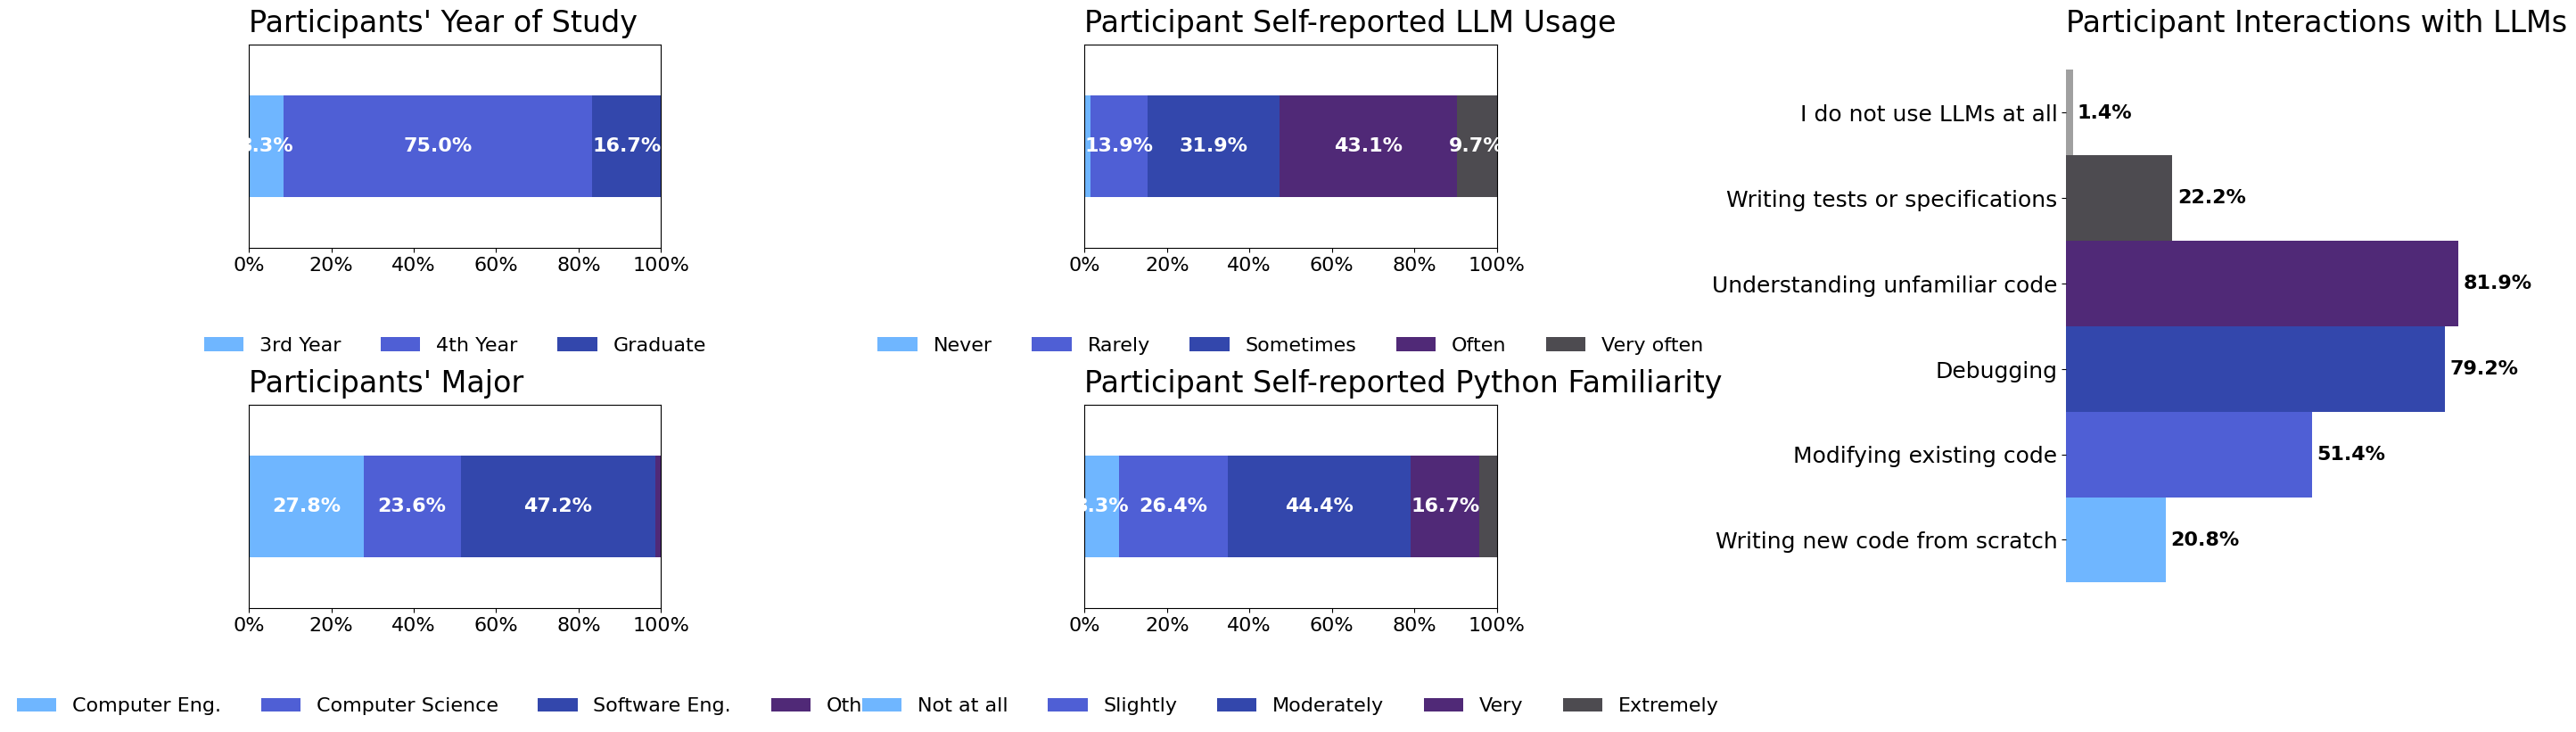

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# -------------------------
# Global font sizes
# -------------------------
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 24,
    'axes.labelsize': 18,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16
})

# -------------------------
# Helper function
# -------------------------
def plot_stacked_bar(ax, data_col, labels_map, colors, title):
    q_labeled = df[data_col].astype(str)
    q_percent = q_labeled.value_counts(normalize=True).sort_index() * 100
    q_df = pd.DataFrame([q_percent])

    q_df.plot(
        kind='barh',
        stacked=True,
        ax=ax,
        color=colors,
        legend=False
    )

    # Titles and axes
    ax.set_title(title, fontsize=24, pad=10, loc='left')
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_yticks([])

    ax.set_xlim(0, 100)
    ax.set_xticks(range(0, 101, 20))
    ax.set_xticklabels(
        [f"{x}%" for x in range(0, 101, 20)],
        fontsize=16
    )

    # Percentage labels inside bars
    for i, val in enumerate(q_percent):
        if val > 5:
            ax.text(
                q_percent[:i].sum() + val / 2,
                0,
                f"{val:.1f}%",
                ha='center',
                va='center',
                color='white',
                fontsize=16,
                fontweight='bold'
            )

    # Custom legend
    custom_labels = [labels_map[k] for k in q_percent.keys()]

    ax.legend(
        handles=ax.patches[:len(custom_labels)],
        labels=custom_labels,
        title="",
        bbox_to_anchor=(0.5, -0.35),
        loc="upper center",
        ncol=len(custom_labels),
        fontsize=16,
        title_fontsize=18,
        frameon=False
    )

# -------------------------
# Plot information
# -------------------------
plots_info = [
    (
        "Q1",
        {'3': "3rd Year", '4': "4th Year", '5': "Graduate"},
        ["#6fb6ff", "#4f5fd5", "#3347ac"],
        "Participants' Year of Study"
    ),

    (
        "Q2",
        {
            'CE': "Computer Eng.",
            'CS': "Computer Science",
            'SE': "Software Eng.",
            "others": "Others"
        },
        ["#6fb6ff", "#4f5fd5", "#3347ac", "#502977"],
        "Participants' Major"
    ),

    (
        "Q3",
        {
            '1.0': "Never",
            '2.0': "Rarely",
            '3.0': "Sometimes",
            "4.0": "Often",
            "5.0": "Very often"
        },
        ["#6fb6ff", "#4f5fd5", "#3347ac", "#502977", "#4D4B50"],
        "Participant Self-reported LLM Usage"
    ),

    (
        "Q5",
        {
            '1.0': "Not at all",
            '2.0': "Slightly",
            '3.0': "Moderately",
            "4.0": "Very",
            "5.0": "Extremely"
        },
        ["#6fb6ff", "#4f5fd5", "#3347ac", "#502977", "#4D4B50"],
        "Participant Self-reported Python Familiarity"
    )
]

# -------------------------
# Create figure
# -------------------------
fig = plt.figure(
    constrained_layout=True,
    figsize=(28, 8)
)

gs = GridSpec(
    2,
    3,
    figure=fig,
    width_ratios=[1, 1, 1]
)

# -------------------------
# Left column
# -------------------------
ax1 = fig.add_subplot(gs[0, 0])
plot_stacked_bar(ax1, *plots_info[0])

ax2 = fig.add_subplot(gs[1, 0])
plot_stacked_bar(ax2, *plots_info[1])

# -------------------------
# Middle column
# -------------------------
ax3 = fig.add_subplot(gs[0, 1])
plot_stacked_bar(ax3, *plots_info[2])

ax4 = fig.add_subplot(gs[1, 1])
plot_stacked_bar(ax4, *plots_info[3])

# -------------------------
# Right column (Q4)
# -------------------------
ax5 = fig.add_subplot(gs[:, 2])

all_values = df["Q4"].dropna().explode()

selection_counts = all_values.value_counts().sort_index()

percentages = selection_counts / len(df) * 100

category_labels = {
    1: "Writing new code from scratch",
    2: "Modifying existing code",
    3: "Debugging",
    4: "Understanding unfamiliar code",
    5: "Writing tests or specifications",
    6: "I do not use LLMs at all"
}

colors = [
    "#6fb6ff",
    "#4f5fd5",
    "#3347ac",
    "#502977",
    "#4D4B50",
    "#a0a0a0"
]

y_labels = [category_labels[k] for k in percentages.index]
x_values = percentages.values
bar_colors = [colors[k - 1] for k in percentages.index]

bars = ax5.barh(
    y_labels,
    x_values,
    color=bar_colors,
    height=1
)

# Q4 title
ax5.set_title(
    "Participant Interactions with LLMs",
    fontsize=24,
    pad=10,
    loc='left'
)

# Remove x-axis
ax5.xaxis.set_visible(False)

# Larger y-axis labels
ax5.set_yticklabels(
    y_labels,
    fontsize=18
)

# Remove spines
for spine in ax5.spines.values():
    spine.set_visible(False)

# Percentage labels
for bar in bars:
    width = bar.get_width()

    ax5.text(
        width + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va='center',
        fontsize=16,
        fontweight='bold'
    )

# -------------------------
# Save figure
# -------------------------
# plt.savefig(
#     "/Users/elmiraonagh/Desktop/Research/Specification_proj_w26/specification_repo/Specification-Completeness-and-Failure-Modes-in-LLM-Assisted-Development/img/demographic_v2.pdf",
#     bbox_inches='tight',
#     dpi=300
# )

plt.show()